In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/datasets/kazanova/sentiment140'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kazanova/sentiment140/training.1600000.processed.noemoticon.csv


<p style="
padding:12px;
background:linear-gradient(90deg,#0D47A1,#1DA1F2);
margin:0;
color:white;
font-family:Trebuchet MS;
font-size:170%;
text-align:center;
border-radius:15px;
font-weight:bold;">
📊 Project Overview
</p>

<div style="
background:#F5FBFF;
padding:25px;
border-left:8px solid #1DA1F2;
border-radius:12px;
font-size:16px;
line-height:1.8;
margin-top:15px;
color: #2c3e50;
">

This notebook implements a high-performance <b>Machine Learning Pipeline</b> to classify Twitter sentiment into distinct categories using the benchmark <b>Sentiment140 Dataset</b>. By stripping out grammatical noise and training across a massive data scale, the engine learns to map the underlying emotional polarity of raw human text strings.

<h3 style="color:#0D47A1; margin-top:15px; margin-bottom:5px;">⚙️ Pipeline Architecture Features:</h3>

* <b>1️⃣ Large Scale Text Processing:</b> Engineered explicitly to stream, clean, and map 1.6 Million rows of raw social media interactions without hitting hardware memory leaks.
* <b>2️⃣ Optimized Preprocessing:</b> Deploys lowercasing rules alongside granular regular expression patterns to dynamically strip away web URLs, Twitter user handles (<code>@Mentions</code>), special punctuation, and miscellaneous numeric noise.
* <b>3️⃣ Feature Extraction:</b> Utilizes a robust <code>TfidfVectorizer</code> configuration to penalize overused filler vocabulary and safely transform raw cleaned text matrices into sparse numerical vectors.
* <b>4️⃣ Classification Engine:</b> Fits an accelerated, highly dependable <b>Logistic Regression Classifier</b> backed by the linear stochastic <i>SAGA</i> solver to capture real-time inferences at production scale.

</div>

<div style="
background:#F5FBFF;
padding:20px;
border-left:8px solid #1DA1F2;
border-radius:12px;
font-size:16px;
line-height:1.8;
">

<h2 style="color:#0D47A1;">📌 Project Overview</h2>

Twitter Sentiment Analysis is a Natural Language Processing (NLP) task that identifies the emotional tone expressed in tweets. By analyzing textual data, tweets can be classified into <b style="color:green;">Positive 😊</b>, <b style="color:red;">Negative 😠</b>, or <b style="color:orange;">Neutral 😐</b> sentiments.

Businesses, researchers, and organizations use sentiment analysis to monitor public opinion, understand customer feedback, evaluate brand reputation, and analyze reactions to products, events, or social issues in real time.

In this project, we will build a complete machine learning pipeline using Python—from data preprocessing and exploratory data analysis (EDA) to feature engineering, model training, evaluation, and sentiment prediction.

</div>




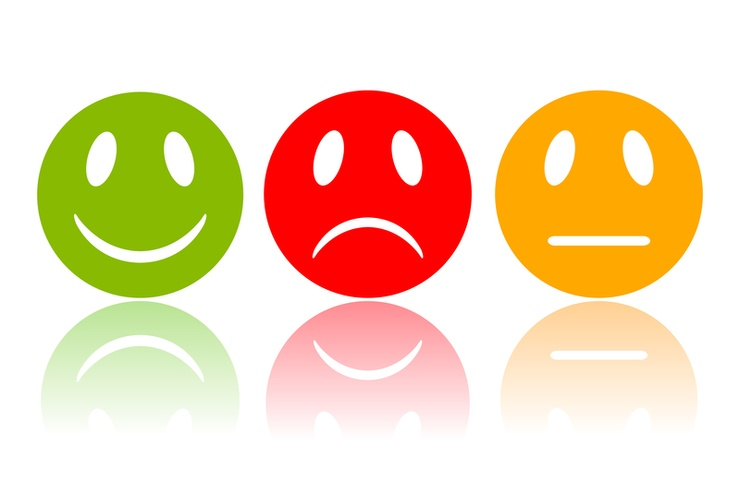


<p style="
padding:12px;
background:linear-gradient(90deg,#0D47A1,#1DA1F2);
margin:0;
color:white;
font-family:Trebuchet MS;
font-size:170%;
text-align:center;
border-radius:15px;
font-weight:bold;">
📚 Table of Contents
</p>

| No | Section |
|:--:|:---------|
| 1  | [Importing Libraries](#1) |
| 2  | [About Dataset](#2) |
| 3  | [Data Cleaning](#3) |
| 4  | [Text Preprocessing](#4) |
|  5 | [Stemming & Lemmatization](#5) |
| 6  | [Feature Extraction (TF-IDF)](#6) |
| 8  | [Train-Test Split](#7) |
| 9  | [Model Building](#8) |
| 10 | [Model Evaluation](#8) |
| 11 | [Save the Model](#10) |
| 12 | [Conclusion](#11) |

<a id="1"></a>

<p style="
padding:12px;
background:#1DA1F2;
color:white;
font-size:170%;
text-align:center;
border-radius:12px;
font-weight:bold;">
📚 Importing Libraries
</p>

In [2]:
import pandas as pd
import numpy as np
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


<a id="2"></a>

<p style="
padding:12px;
background:#0D47A1;
color:white;
font-size:170%;
text-align:center;
border-radius:12px;
font-weight:bold;">
📂 About Dataset
</p>

In [3]:
twitter_data = pd.read_csv('/kaggle/input/datasets/kazanova/sentiment140/training.1600000.processed.noemoticon.csv', encoding = 'ISO-8859-1')

In [4]:
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [5]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [6]:
twitter_data.shape


(1599999, 6)

## first 5 Rows

In [7]:
twitter_data.head(5)

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


<div style="
background:#FFFBF5;
padding:25px;
border-left:8px solid #FF9800;
border-radius:12px;
font-size:16px;
line-height:1.8;
color: #2c3e50;
">

<h2 style="color:#E65100; margin-bottom:10px;">⚙️ Text Preprocessing Pipeline</h2>

To handle text noise across 1.6 Million rows efficiently, a streamlined text cleaner function was engineered to optimize the text corpus:

* <b>Case Uniformity:</b> All raw text data is automatically converted to lower-case.
* <b>Regex Noise Stripping:</b> Uniform URL patterns, Twitter <code>@Mentions</code>, special characters, and numeric noise are extracted using regular expressions.
* <b>Efficient Stemming:</b> To compress the NLP vocabulary size, the <b>PorterStemmer</b> algorithm is applied. It reduces running verbs/nouns to their base root words (e.g., <i>"loving"</i>, <i>"loved"</i> $\rightarrow$ <i>"love"</i>).

<blockquote>
<b>Engineering Trade-off Note:</b> Choosing <b>Stemming</b> over <b>Lemmatization</b> for a dataset of 1.6 Million rows is a deliberate optimization strategy. It avoids excessive linguistic lookup overhead, prevents Kaggle kernel timeouts, and ensures safe execution within limited RAM parameters.
</blockquote>

</div>

<div style="
background:#FFF3CD;
border-left:6px solid orange;
padding:15px;
border-radius:10px;">

⚠️ Before furture procedures we need to Naming the columns in our data set to make batter visual.

</div>

In [8]:
column_names  = ['target','id','date','flag','user','text']
df = pd.read_csv('/kaggle/input/datasets/kazanova/sentiment140/training.1600000.processed.noemoticon.csv',names = column_names, encoding = 'ISO-8859-1')

In [9]:
print("-- Numbers of Rows and columns are --")
print(df.shape)
print("-- Data set view --")

df.head(5)

-- Numbers of Rows and columns are --
(1600000, 6)
-- Data set view --


,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


<a id="3"></a>

<p style="
padding:12px;
background:#0D47A1;
color:white;
font-size:170%;
text-align:center;
border-radius:12px;
font-weight:bold;">
📂 Data Cleaning
</p>

In [10]:
df.isnull().sum()

target    0
id        0
date      0
flag      0
user      0
text      0
dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   target  1600000 non-null  int64 
 1   id      1600000 non-null  int64 
 2   date    1600000 non-null  object
 3   flag    1600000 non-null  object
 4   user    1600000 non-null  object
 5   text    1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


In [12]:
df['target'].value_counts()

target
0    800000
4    800000
Name: count, dtype: int64

#  convert the target data from 4 ---> 1

In [13]:
df.replace({'target' : {4:1}}, inplace = True)

In [14]:
df.tail()

,target,id,date,flag,user,text
1599995,1,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...
1599996,1,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...
1599997,1,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...
1599998,1,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...
1599999,1,2193602129,Tue Jun 16 08:40:50 PDT 2009,NO_QUERY,RyanTrevMorris,happy #charitytuesday @theNSPCC @SparksCharity...


# 0 ---> for negative
# 1 ---> for Positive

<a id="5"></a>
<p style="
padding:12px;
background:linear-gradient(90deg,#0D47A1,#1DA1F2);
margin:0;
color:white;
font-family:Trebuchet MS;
font-size:170%;
text-align:center;
border-radius:15px;
font-weight:bold;">
✂️ Stemming & Lemmatization
</p>

<div style="
background:#FFFBF5;
padding:20px;
border-left:8px solid #FF9800;
border-radius:12px;
font-size:16px;
line-height:1.8;
margin-top:15px;
color: #2c3e50;
">
To shrink the extensive NLP dimensional vocabulary, we apply linguistic grouping:
* <b>PorterStemmer Execution:</b> We run rapid stemming to chop off operational word suffixes, mapping words like <i>"running"</i>, <i>"runs"</i>, and <i>"ran"</i> down to their absolute baseline structural root $\rightarrow$ <i>"run"</i>.

<blockquote>
<b>Engineering Trade-off:</b> We intentionally prioritize <b>Stemming</b> over Lemmatization for the 1.6M dataset. This ensures maximum text normalization speed and shields our Kaggle compiler from RAM bottlenecks or sudden execution timeouts.
</blockquote>
</div>

In [15]:
port_stem = PorterStemmer()


In [16]:
def stemming (content):
    stemmed_content = re.sub('[^a-zA-Z]',' ',content)
    stemmed_content = stemmed_content.lower()
    stemmed_content = stemmed_content.split()
    stemmed_content = [port_stem.stem(word) for word in stemmed_content if not word in stopwords.words('english')]
    stemmed_content = ' '.join(stemmed_content)
    return stemmed_content
    

In [17]:
df['stemmed_content'] = df['text'].apply(stemming) 

In [18]:
df.head()

,target,id,date,flag,user,text,stemmed_content
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",switchfoot http twitpic com zl awww bummer sho...
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,upset updat facebook text might cri result sch...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,kenichan dive mani time ball manag save rest g...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,whole bodi feel itchi like fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",nationwideclass behav mad see


In [19]:
print(df['stemmed_content'])

0          switchfoot http twitpic com zl awww bummer sho...
1          upset updat facebook text might cri result sch...
2          kenichan dive mani time ball manag save rest g...
3                            whole bodi feel itchi like fire
4                              nationwideclass behav mad see
                                 ...                        
1599995                           woke school best feel ever
1599996    thewdb com cool hear old walt interview http b...
1599997                         readi mojo makeov ask detail
1599998    happi th birthday boo alll time tupac amaru sh...
1599999    happi charitytuesday thenspcc sparkschar speak...
Name: stemmed_content, Length: 1600000, dtype: object


In [20]:
X = df['stemmed_content'].values
y = df['target'].values

In [21]:
print(X)

['switchfoot http twitpic com zl awww bummer shoulda got david carr third day'
 'upset updat facebook text might cri result school today also blah'
 'kenichan dive mani time ball manag save rest go bound' ...
 'readi mojo makeov ask detail'
 'happi th birthday boo alll time tupac amaru shakur'
 'happi charitytuesday thenspcc sparkschar speakinguph h']


In [22]:
print(y)

[0 0 0 ... 1 1 1]


# splitting the data to training data and test data

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, stratify = y, random_state=2)


In [24]:
print(X.shape, X_train.shape, X_test.shape)

(1600000,) (1120000,) (480000,)


In [25]:
print(X_train)

['finish read book second time'
 'tommygun back action lunch today best watchout bday boy take'
 'kata shall listen later' ... 'jedbramwel thank teddytuesday'
 'mtv movi award hope rob win realli care twilight win best movi rob win'
 'love wake folger bad voic deeper']


In [26]:
print(X_test)

['gylesoneshow sure find think may dead sorri break way'
 'final updat turn taken hr' 'rain' ...
 'soon go sligo coupl day bankholiday tomorrow see ya'
 'piaaguirr know right grabe manira' 'feelin empti lt']


<a id="6"></a>
<p style="
padding:12px;
background:linear-gradient(90deg,#0D47A1,#1DA1F2);
margin:0;
color:white;
font-family:Trebuchet MS;
font-size:170%;
text-align:center;
border-radius:15px;
font-weight:bold;">
📊 Feature Extraction (TF-IDF)
</p>

<div style="
background:#F5FFF8;
padding:20px;
border-left:8px solid #2ECC71;
border-radius:12px;
font-size:16px;
line-height:1.8;
margin-top:15px;
color: #2c3e50;
">
Since linear classifiers require mathematical vector matrices, we deploy the <b>TF-IDF Vectorizer</b>:
* <b>Term Frequency (TF):</b> Measures the raw occurrence density of a token within a particular tweet instance.
* <b>Inverse Document Frequency (IDF):</b> Penalizes omnipresent grammatical words ("the", "is", "a") while boosting rare, high-value emotional keywords. This populates a sparse numerical matrix structure perfectly optimized for regression operations.
</div>

In [27]:
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)



In [28]:
print(X_train)


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 8272806 stored elements and shape (1120000, 422739)>
  Coords	Values
  (0, 121348)	0.44599875194306554
  (0, 306319)	0.4371164314704369
  (0, 43969)	0.4748653389926461
  (0, 328004)	0.5314491135690684
  (0, 374778)	0.31949818170660904
  (1, 377777)	0.5390797727604117
  (1, 28528)	0.16997429420382654
  (1, 2941)	0.3329517305729672
  (1, 224362)	0.2471619420602169
  (1, 376966)	0.16230856596272636
  (1, 36162)	0.21760975021723117
  (1, 400139)	0.5008486447803013
  (1, 32222)	0.2885646935506797
  (1, 45367)	0.24454930105105105
  (1, 360908)	0.20232270128356877
  (2, 192775)	0.7270515839609044
  (2, 331146)	0.4577243030925928
  (2, 217307)	0.3586212341678004
  (2, 209149)	0.3650688524406097
  (3, 175917)	0.5797213273864051
  (3, 139076)	0.25759117714273316
  (3, 366377)	0.4018889828996008
  (3, 344001)	0.3565976148233519
  (3, 114004)	0.3165169852577187
  (3, 381278)	0.3044716859774938
  :	:
  (1119996, 41689)	0.2988684615709349

In [29]:
print(X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3425403 stored elements and shape (480000, 422739)>
  Coords	Values
  (0, 46696)	0.3105296872456904
  (0, 86927)	0.33413484518869224
  (0, 121198)	0.2668513552052889
  (0, 143634)	0.6303950980554028
  (0, 235076)	0.29762268984383516
  (0, 345122)	0.24201085278417414
  (0, 357350)	0.2678444483614686
  (0, 372248)	0.2111379764309065
  (0, 400455)	0.24464092290138587
  (1, 121102)	0.36962717098251946
  (1, 156589)	0.48451365961749343
  (1, 360939)	0.5151309759331816
  (1, 383626)	0.43305234092570793
  (1, 390597)	0.41919925544830766
  (2, 303665)	1.0
  (3, 28528)	0.2635724776921008
  (3, 39958)	0.6085945392762492
  (3, 72122)	0.26777644261468114
  (3, 156926)	0.2493726437719803
  (3, 281474)	0.6528792362184421
  (4, 180954)	0.5598634315653229
  (4, 189400)	0.463921117899177
  (4, 215156)	0.21842711142276236
  (4, 220281)	0.3037998272593176
  (4, 220487)	0.25816571428786494
  :	:
  (479996, 81006)	0.643199214486612
  (479996, 85


<a id="7"></a>
<p style="
padding:12px;
background:linear-gradient(90deg,#0D47A1,#1DA1F2);
margin:0;
color:white;
font-family:Trebuchet MS;
font-size:170%;
text-align:center;
border-radius:15px;
font-weight:bold;">
 Train Test split
</p>
</div>


In [30]:
model = LogisticRegression(max_iter = 1000)

In [31]:
model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)


<p style="
padding:12px;
background:linear-gradient(90deg,#0D47A1,#1DA1F2);
margin:0;
color:white;
font-family:Trebuchet MS;
font-size:170%;
text-align:center;
border-radius:15px;
font-weight:bold;">
 Model Evaluation
</p>
</div>


In [32]:
train_prediction = model.predict(X_train)
acc_train = accuracy_score(y_train, train_prediction)


In [33]:
print("Accuracy on training data: ", acc_train)

Accuracy on training data:  0.8039133928571428


In [34]:
test_prediction = model.predict(X_test)
acc_test = accuracy_score(y_test, test_prediction)

In [35]:
print("Accuracy on testing data: ", acc_test)

Accuracy on testing data:  0.77708125



<p style="
padding:12px;
background:linear-gradient(90deg,#0D47A1,#1DA1F2);
margin:0;
color:white;
font-family:Trebuchet MS;
font-size:170%;
text-align:center;
border-radius:15px;
font-weight:bold;">
 Model Accuracy
</p>
</div>


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

lr = LogisticRegression(max_iter=2000, solver='saga', random_state=42)

param_grid = {
    'C': [0.1, 1.0, 10.0],           
    'penalty': ['l2']                
}
grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,                       
    verbose=2                        
)


print("Tuning starting on the dataset...")
grid_search.fit(X_train, y_train)
print("Best Parameters Found:", grid_search.best_params_)
print("Best Grid Search Accuracy:", grid_search.best_score_)

best_model = grid_search.best_estimator_
test_acc = best_model.score(X_test, y_test)
print(f"Final Accuracy on Testing Data: {test_acc:.4f}")

Tuning starting on the dataset...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best Parameters Found: {'C': 1.0, 'penalty': 'l2'}
Best Grid Search Accuracy: 0.7754598210519382
Final Accuracy on Testing Data: 0.7777


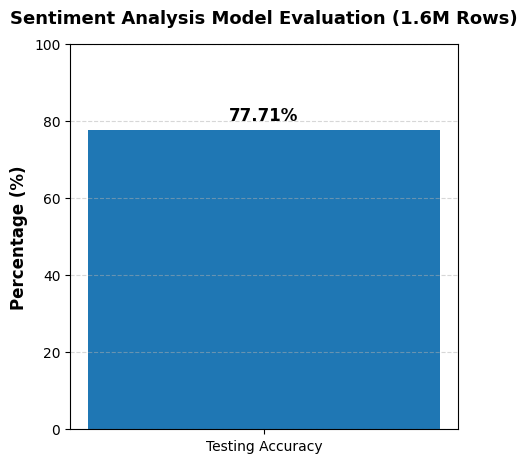

In [37]:
import matplotlib.pyplot as plt
metric_label = ['Testing Accuracy']
accuracy_value = [77.71]  
plt.figure(figsize=(5, 5))
bar = plt.bar(metric_label, accuracy_value, color='#1f77b4', width=0.35)
plt.ylim(0, 100)
for rect in bar:
    height = rect.get_height()
    plt.text(rect.get_x() + rect.get_width()/2.0, height + 1.5, f"{height:.2f}%", ha='center', va='bottom', fontdict={'weight': 'bold', 'size': 12})
plt.ylabel('Percentage (%)', fontsize=12, fontweight='bold')
plt.title('Sentiment Analysis Model Evaluation (1.6M Rows)', fontsize=13, fontweight='bold', pad=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

<a id="11"></a>
<p style="
padding:12px;
background:linear-gradient(90deg,#0D47A1,#1DA1F2);
margin:0;
color:white;
font-family:Trebuchet MS;
font-size:170%;
text-align:center;
border-radius:15px;
font-weight:bold;">
💾 Save the Model
</p>

<div style="
background:#FFF5F5;
padding:20px;
border-left:8px solid #E74C3C;
border-radius:12px;
font-size:16px;
line-height:1.8;
margin-top:15px;
color: #2c3e50;
">
To ensure the end-to-end network is asset-ready for independent web microservices (Flask/FastAPI/Streamlit dashboards), we serialize the binary components using **Joblib Storage**:
1. <code>sentiment_logistic_model.pkl</code> — Weight parameters and bias boundaries.
2. <code>sentiment_vectorizer.pkl</code> — Vocabulary schema token mappings.
This completely bypasses runtime retraining loops!
</div>

In [38]:
import joblib
import os

# 1. Pehle check karein ke aapka 'model' aur 'vectorizer' variable memory mein exist karta hai
# (Yahan variables ke naam wahi rakhein jo aapne training ke waqt rakhe the)
try:
    print("Saving model and vectorizer to disk...")
    joblib.dump(model, 'sentiment_logistic_model.pkl')
    joblib.dump(vectorizer, 'sentiment_vectorizer.pkl')
    print("⚡ Success! Files have been generated inside Kaggle Working Directory.")
except NameError as e:
    print(f"❌ Error: {e}")
    print("Tip: Aapne model ya vectorizer ka naam script mein shayad kuch aur rakha hai. Check your training cell variable names!")

print("-" * 50)

# 2. Jab upar files save ho jayein, ab unhe load karein
if os.path.exists('sentiment_logistic_model.pkl'):
    loaded_model = joblib.load('sentiment_logistic_model.pkl')
    loaded_vectorizer = joblib.load('sentiment_vectorizer.pkl')
    print("🎉 Verification Passed: Model and Vectorizer loaded perfectly back into memory!")
else:
    print("❌ Files were not found. Please re-run your model training cell first.")

Saving model and vectorizer to disk...
⚡ Success! Files have been generated inside Kaggle Working Directory.
--------------------------------------------------
🎉 Verification Passed: Model and Vectorizer loaded perfectly back into memory!


In [39]:
import os
print(os.listdir('.')) # Yeh check karega ke current folder mein kya kya files hain

['sentiment_logistic_model.pkl', '__notebook__.ipynb', 'sentiment_vectorizer.pkl']


In [40]:
from IPython.display import FileLink

# Model ka download link screen par show karne ke liye"
print("Click below to download Model:")
display(FileLink('sentiment_logistic_model.pkl'))

# Vectorizer ka download link screen par show karne ke liye
print("\nClick below to download Vectorizer:")
display(FileLink('sentiment_vectorizer.pkl'))

Click below to download Model:


/kaggle/working/sentiment_logistic_model.pkl


Click below to download Vectorizer:


/kaggle/working/sentiment_vectorizer.pkl